# DS570 Term Project — Model Experiments & Ablation Study
**AI-Assisted Signal Regeneration in Critical CAN Bus Interruptions**

This notebook consolidates every numerical experiment behind the presentation:

1. Data loading & sanity checks (anonymized, MinMax-scaled telemetry)
2. Chronological train/test split (temporal-leakage prevention)
3. Baseline (Linear Regression) vs. Advanced (Random Forest) training
4. Interpretability: LR coefficients & RF feature importances
5. Bias–variance / in-sample vs. out-of-sample analysis
6. **Sensor-loss ablation study** (FuSa redundancy validation)
7. Physical-scale (km/h) interpretation of the error metrics
8. Model artifact export (`models/`)

All results are deterministic (`random_state=42`, `shuffle=False`) — running
this notebook end-to-end reproduces every number quoted on the slides.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import sklearn
print("scikit-learn:", sklearn.__version__)

SEED = 42
ALL_FEATURES = [f"Signal_X{i}" for i in range(1, 12)]
TARGET = "Signal_Y"
Path("models").mkdir(exist_ok=True)

scikit-learn: 1.8.0


## 1 · Data Loading

The dataset is exported with a **semicolon delimiter and decimal comma**
(Turkish locale). All signals are anonymized (`Signal_X1…X11`) and
MinMax-scaled to **[0, 1]** for NDA compliance; `Signal_Y` is the scaled
Vehicle Speed target.

In [2]:
df = pd.read_csv("Finalized_Dataset.csv", sep=";", decimal=",")
df.columns = df.columns.str.strip()

assert all(pd.api.types.is_numeric_dtype(df[c]) for c in ALL_FEATURES + [TARGET])
print(f"Rows: {len(df):,}   ·   Columns: {list(df.columns)}")
df[ALL_FEATURES + [TARGET]].describe().loc[["min", "max", "mean"]].round(4)

Rows: 104,840   ·   Columns: ['TimeStamp', 'Signal_X1', 'Signal_X2', 'Signal_X3', 'Signal_X4', 'Signal_X5', 'Signal_X6', 'Signal_X7', 'Signal_X8', 'Signal_X9', 'Signal_X10', 'Signal_X11', 'Signal_Y']


,Signal_X1,Signal_X2,Signal_X3,Signal_X4,Signal_X5,Signal_X6,Signal_X7,Signal_X8,Signal_X9,Signal_X10,Signal_X11,Signal_Y
min,0.000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.00,0.0000
max,1.000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.00,1.0000
mean,0.382,0.5425,0.5028,0.8281,0.1629,0.2052,0.2611,0.2942,0.2323,0.4672,0.45,0.2586


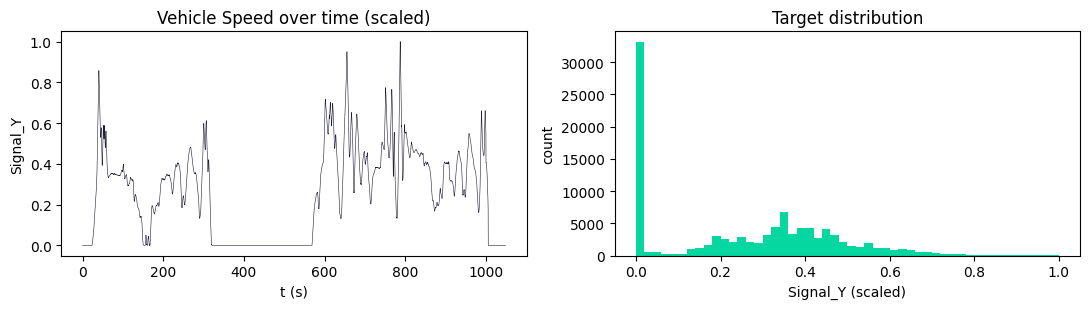

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].plot(df["TimeStamp"], df[TARGET], lw=0.4, color="#1c1b35")
ax[0].set(title="Vehicle Speed over time (scaled)", xlabel="t (s)", ylabel="Signal_Y")
ax[1].hist(df[TARGET], bins=50, color="#06D6A0")
ax[1].set(title="Target distribution", xlabel="Signal_Y (scaled)", ylabel="count")
plt.tight_layout(); plt.show()

## 2 · Chronological Train/Test Split

Telemetry is a **time series sampled on a 10 ms grid**: consecutive frames are
nearly identical. A random split would scatter near-duplicate frames across
train and test, leaking the future into training and inflating test scores
(**temporal leakage**). We therefore use `shuffle=False`: the first 80% of the
drive trains the models, the final 20% — the *unseen future* — tests them.
This mirrors the production scenario.

In [4]:
X, y = df[ALL_FEATURES], df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
print(f"Train: {len(X_train):,} rows   ·   Test: {len(X_test):,} rows (chronological tail)")

Train: 83,872 rows   ·   Test: 20,968 rows (chronological tail)


## 3 · Model Training

* **Baseline — Linear Regression.** Vehicle speed is physically linear in its
  proxies (V = r·ω), so a linear model is the principled reference point.
* **Advanced — Random Forest.** 50 trees, `max_depth=12`: captures non-linear,
  conditional couplings between redundant channels and the target —
  the property that matters under sensor loss (Section 6).

In [5]:
def evaluate(model, X_tr, y_tr, X_te, y_te):
    tr, te = model.predict(X_tr), model.predict(X_te)
    return dict(
        train_R2=r2_score(y_tr, tr), test_R2=r2_score(y_te, te),
        train_MAE=mean_absolute_error(y_tr, tr) * 1e3,
        test_MAE=mean_absolute_error(y_te, te) * 1e3,
        train_RMSE=np.sqrt(mean_squared_error(y_tr, tr)) * 1e3,
        test_RMSE=np.sqrt(mean_squared_error(y_te, te)) * 1e3,
    )

linear_model = LinearRegression().fit(X_train, y_train)
advanced_model = RandomForestRegressor(
    n_estimators=50, max_depth=12, random_state=SEED, n_jobs=-1, bootstrap=True
).fit(X_train, y_train)

results = pd.DataFrame({
    "Linear Regression": evaluate(linear_model, X_train, y_train, X_test, y_test),
    "Random Forest":     evaluate(advanced_model, X_train, y_train, X_test, y_test),
}).T
results.round(4)

,train_R2,test_R2,train_MAE,test_MAE,train_RMSE,test_RMSE
Linear Regression,0.9999,0.9998,1.1790,1.5384,2.0391,2.6873
Random Forest,1.0000,0.9998,0.4483,1.3302,0.7755,2.4136


## 4 · Interpretability — Where Do the Models Look?

Both architectures, trained independently, concentrate on the same two
channels: **X7 (wheel speed)** and **X8 (inverter RPM)** — the direct physical
proxies of vehicle speed. ML output agreeing with domain physics validates
that the models learned mechanism, not spurious correlation.

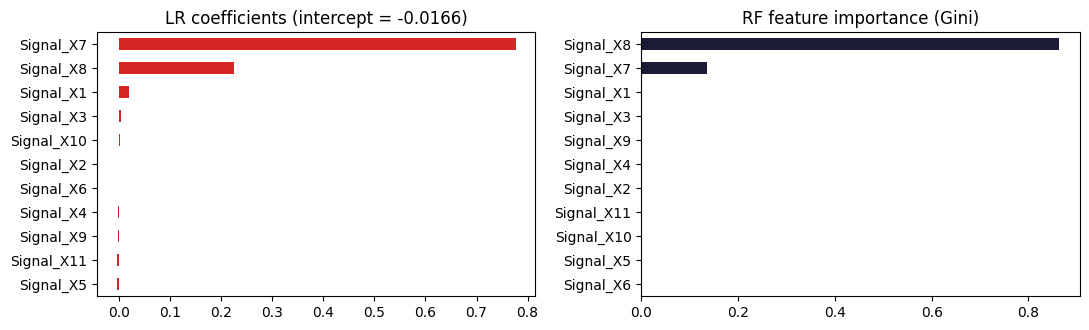

,LR β,RF importance
Signal_X8,0.2262,0.8632
Signal_X7,0.7764,0.1367
Signal_X1,0.0195,0.0000
Signal_X3,0.0032,0.0000
Signal_X9,-0.0026,0.0000
Signal_X4,-0.0018,0.0000
Signal_X2,0.0005,0.0000
Signal_X11,-0.0036,0.0000
Signal_X10,0.0024,0.0000
Signal_X5,-0.0044,0.0000


In [6]:
coef = pd.Series(linear_model.coef_, index=ALL_FEATURES, name="LR β")
imp  = pd.Series(advanced_model.feature_importances_, index=ALL_FEATURES, name="RF importance")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
coef.sort_values().plot.barh(ax=ax[0], color="#d62728")
ax[0].set_title(f"LR coefficients (intercept = {linear_model.intercept_:.4f})")
imp.sort_values().plot.barh(ax=ax[1], color="#1c1b35")
ax[1].set_title("RF feature importance (Gini)")
plt.tight_layout(); plt.show()

pd.concat([coef, imp], axis=1).sort_values("RF importance", ascending=False).round(4)

## 5 · Bias–Variance: In-Sample vs. Out-of-Sample

* **In-sample (train) error** measures model *capacity* → low ⇒ low bias.
* **The train→test gap** measures *memorization* → small ⇒ low variance.

LR is structurally stable (12 parameters vs. 83k samples). RF's individual
depth-12 trees partially memorize the train set (gap ≈ 3×), but bootstrap
averaging across 50 decorrelated trees cancels that variance: ΔR² ≈ 0 and the
*absolute* test error is still the lowest. Optimistic training error — yes;
harmful overfitting — no.

In [7]:
gap = pd.DataFrame({
    "test/train MAE ratio": results["test_MAE"] / results["train_MAE"],
    "ΔR² (train − test)":   results["train_R2"] - results["test_R2"],
})
gap.round(4)

,test/train MAE ratio,ΔR² (train − test)
Linear Regression,1.3048,0.0002
Random Forest,2.9670,0.0002


## 6 · Sensor-Loss Ablation Study (FuSa Validation)

Feature importance said the 9 secondary channels contribute ~0% — but
**importance ≠ capability**: it only means they are unused *while X7/X8 are
present*. Here both models are **retrained from scratch** under four
sensor-availability scenarios to measure what the redundant channels can do
when the physical proxies disappear (hardware failure / spoofing).

In [8]:
scenarios = [
    ("Baseline (all 11)", [],                         "all11"),
    ("Drop X7",           ["Signal_X7"],              "drop_x7"),
    ("Drop X8",           ["Signal_X8"],              "drop_x8"),
    ("Drop X7 + X8",      ["Signal_X7", "Signal_X8"], "drop_x7x8"),
]

rows, baseline_mae = [], {}
for name, drop, tag in scenarios:
    feats = [f for f in ALL_FEATURES if f not in drop]
    Xtr, Xte, ytr, yte = train_test_split(df[feats], y, test_size=0.2, shuffle=False)
    for mname, model, prefix in [
        ("Linear Regression", LinearRegression(), "linear_model"),
        ("Random Forest", RandomForestRegressor(n_estimators=50, max_depth=12,
                          random_state=SEED, n_jobs=-1, bootstrap=True), "advanced_model"),
    ]:
        model.fit(Xtr, ytr)
        p = model.predict(Xte)
        mae = mean_absolute_error(yte, p) * 1e3
        if tag == "all11":
            baseline_mae[mname] = mae
        rows.append(dict(Scenario=name, Model=mname,
                         test_R2=r2_score(yte, p), test_MAE=mae,
                         MAE_multiplier=mae / baseline_mae[mname]))
        # export every ablation artifact (baseline = the production models)
        suffix = "" if tag == "all11" else f"_{tag}"
        joblib.dump(model, f"models/{prefix}{suffix}.joblib")

ablation = pd.DataFrame(rows)
ablation.round(4)

,Scenario,Model,test_R2,test_MAE,MAE_multiplier
0,Baseline (all 11),Linear Regression,0.9998,1.5384,1.0000
1,Baseline (all 11),Random Forest,0.9998,1.3302,1.0000
2,Drop X7,Linear Regression,0.9998,1.4551,0.9459
3,Drop X7,Random Forest,0.9997,1.4675,1.1032
4,Drop X8,Linear Regression,0.9997,1.7889,1.1629
5,Drop X8,Random Forest,0.9996,1.8429,1.3854
6,Drop X7 + X8,Linear Regression,0.0371,111.0001,72.1551
7,Drop X7 + X8,Random Forest,0.9731,17.8642,13.4292


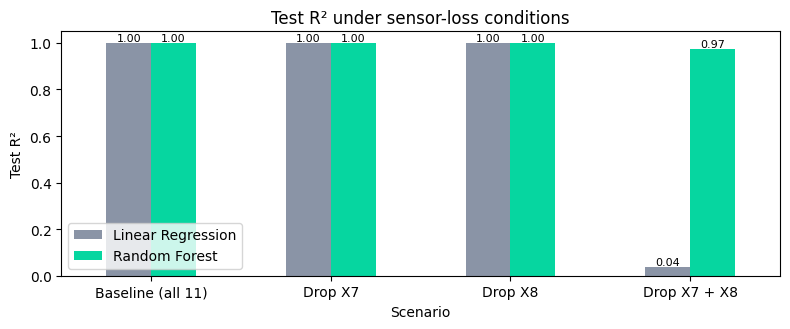

In [9]:
piv = ablation.pivot(index="Scenario", columns="Model", values="test_R2")
piv = piv.reindex([s[0] for s in scenarios])
axp = piv.plot.bar(figsize=(8, 3.4), color=["#8A94A6", "#06D6A0"], rot=0)
axp.set(title="Test R² under sensor-loss conditions", ylabel="Test R²")
axp.legend(loc="lower left")
for c in axp.containers:
    axp.bar_label(c, fmt="%.2f", fontsize=8)
plt.tight_layout(); plt.show()

**Reading the result.** Single-sensor loss is harmless for both models —
X7 and X8 are mutual physical proxies, so one covers for the other. The
separation appears only in the **crisis scenario** (both proxies lost):

* Linear Regression collapses to noise level (R² ≈ 0.04, MAE ×72.2) — the
  remaining signal↔speed relationships are non-linear and outside its
  hypothesis space (*structural bias under distribution shift*).
* Random Forest degrades gracefully (R² ≈ 0.97, MAE ×13.4) — its threshold
  splits rediscover the conditional physics of the redundant channels.

This is the FuSa value of the pipeline: *fail-operational* instead of
*fail-silent*.

In [10]:
crisis = joblib.load("models/advanced_model_drop_x7x8.joblib")
redist = pd.Series(crisis.feature_importances_, index=crisis.feature_names_in_)
redist = redist.sort_values(ascending=False)
print("Importance redistribution in the crisis model (no X7/X8):")
print(redist.round(4).to_string())
print(f"\nTop backup channel: {redist.index[0]} = {redist.iloc[0]:.1%}  "
      "(regen torque — can only exist while the motor spins: a conditional, "
      "non-linear physical coupling)")

Importance redistribution in the crisis model (no X7/X8):
Signal_X11    0.9584
Signal_X4     0.0129
Signal_X9     0.0098
Signal_X5     0.0092
Signal_X1     0.0043
Signal_X10    0.0039
Signal_X6     0.0008
Signal_X3     0.0005
Signal_X2     0.0001

Top backup channel: Signal_X11 = 95.8%  (regen torque — can only exist while the motor spins: a conditional, non-linear physical coupling)


## 6b · Temporal Cross-Validation (Expanding Window)

Classic *k*-fold CV is **invalid** for this dataset: shuffling 10 ms frames
would train on the future and test on the past (temporal leakage). The
time-series-appropriate equivalent is `TimeSeriesSplit` — an **expanding
window**: train on the first chunk, test on the next; grow the window; repeat.
Every fold respects causality, and fold-to-fold stability measures the
**variance** of the models across different drive segments.

In [11]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)
cv_rows = []
for fold, (tr, te) in enumerate(tscv.split(X), 1):
    for mname, mdl in [
        ("Linear Regression", LinearRegression()),
        ("Random Forest", RandomForestRegressor(n_estimators=50, max_depth=12,
                          random_state=SEED, n_jobs=-1, bootstrap=True)),
    ]:
        mdl.fit(X.iloc[tr], y.iloc[tr])
        p = mdl.predict(X.iloc[te])
        cv_rows.append(dict(fold=fold, model=mname,
                            test_R2=r2_score(y.iloc[te], p),
                            test_MAE_e3=mean_absolute_error(y.iloc[te], p) * 1e3,
                            y_var_test=float(y.iloc[te].var())))

cv = pd.DataFrame(cv_rows)
cv.pivot(index="fold", columns="model",
         values=["test_R2", "test_MAE_e3", "y_var_test"]).round(4)

test_R2                     test_MAE_e3                \
model Linear Regression Random Forest Linear Regression Random Forest   
fold                                                                    
1                0.9998        0.9998            1.4007        1.4654   
2                0.0000        0.0000            0.1650        0.0004   
3                0.9999        0.9990            1.3405        2.3322   
4                0.9995        0.9992            1.8097        1.7697   
5                0.9998        0.9998            1.5161        1.2826   

             y_var_test                
model Linear Regression Random Forest  
fold                                   
1                0.0245        0.0245  
2                0.0000        0.0000  
3                0.0652        0.0652  
4                0.0184        0.0184  
5                0.0334        0.0334

**Reading the folds.** Fold 2 reports R² = 0 for *both* models — yet its MAE is
the lowest of all folds (RF ≈ 4×10⁻⁷). The `y_var_test` column explains why:
that test window covers a segment where the vehicle is **stationary**
(`Signal_Y ≡ 0`), so the variance in the R² denominator is zero and the metric
is undefined — not a model failure. This is a textbook illustration of why R²
must be read together with MAE on segmented time series.

Excluding the degenerate zero-variance fold, both models are **stable across
all drive segments** — the single 80/20 split was not a lucky draw:

In [12]:
valid = cv[cv.y_var_test > 0]
summary = valid.groupby("model").agg(
    R2_mean=("test_R2", "mean"), R2_std=("test_R2", "std"),
    MAE_mean=("test_MAE_e3", "mean"), MAE_std=("test_MAE_e3", "std"),
).round(4)
summary

,R2_mean,R2_std,MAE_mean,MAE_std
model,,,,
Linear Regression,0.9998,0.0002,1.5167,0.2085
Random Forest,0.9995,0.0004,1.7125,0.4594


## 7 · Physical Scale of the Errors

Metrics above live in the MinMax-scaled [0, 1] domain. The inverse transform is
`error_kmh = scaled_error × (V_max − V_min)`. Applying it to the baseline test
errors places **MAE ≤ 0.16 km/h and RMSE ≤ 0.27 km/h for both models** — below
typical speedometer display resolution. (The exact speed range is withheld
here in line with the NDA; the bound is conservative.)

## 8 · Exported Artifacts & Reproducibility

All eight models (2 production + 6 ablation) are saved under `models/`.
Every result is deterministic: fixed `random_state=42`, chronological split,
pinned scikit-learn version printed in cell 1 — re-running the notebook
reproduces each number on the slides bit-for-bit.

In [13]:
for f in sorted(Path("models").glob("*.joblib")):
    print(f"{f.name:38s} {f.stat().st_size/1e6:7.2f} MB")

advanced_model.joblib                    23.19 MB
advanced_model_drop_x7.joblib            23.13 MB
advanced_model_drop_x7x8.joblib          10.83 MB
advanced_model_drop_x8.joblib            23.47 MB
linear_model.joblib                       0.00 MB
linear_model_drop_x7.joblib               0.00 MB
linear_model_drop_x7x8.joblib             0.00 MB
linear_model_drop_x8.joblib               0.00 MB
